# Tarea 2 — Analisis de Cartera con Predicciones
Usa el **mejor modelo de la Parte 2 (investigacion)** para ventana de salida = 90 dias.
El modelo se entrenó con preprocesado del Taller B3-T1:
- **Diferenciacion fraccional (FFD)** — Lopez de Prado (2018), Snippets 5.3-5.4
- **Denoising Marchenko-Pastur** — Lopez de Prado (2020)
- **StandardScaler** ajustado solo sobre train

Evaluacion sobre datos de 2025: cartera SIN vs CON predicciones.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity
from scipy.optimize import minimize_scalar
from statsmodels.tsa.stattools import adfuller

from utilidades.carga_datos import cargar_retornos, create_time_series_data, dividir_datos, aplanar_X
from utilidades.evaluacion  import cargar_todos_resultados
from utilidades.modelos     import construir_dense, construir_recurrente, construir_conv1d, construir_mixto
from keras.callbacks import EarlyStopping, ReduceLROnPlateau


## Funciones de preprocesado (FFD + Marchenko-Pastur)

In [2]:
# ── Diferenciacion fraccional FFD ────────────────────────────────────────
def get_weights_ffd(d, threshold=1e-5, max_width=None):
    w = [1.0]
    k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k)
        k += 1
        if max_width and len(w) >= max_width:
            break
    return np.array(w[::-1])

def frac_diff_ffd(series, d, threshold=1e-5, max_width=None):
    if max_width is None:
        max_width = len(series)
    weights = get_weights_ffd(d, threshold, max_width=max_width)
    width = len(weights)
    if width > len(series):
        return pd.Series(dtype=float)
    vals = series.values
    # Usar lista en lugar de dict para evitar desalineacion con DatetimeIndex
    result_vals = [
        np.dot(weights, vals[i - width + 1 : i + 1])
        for i in range(width - 1, len(vals))
    ]
    return pd.Series(result_vals, index=series.index[width - 1:])

def encontrar_d_minimo(serie, d_values=None, threshold=1e-5, pvalue=0.05):
    if d_values is None:
        d_values = np.arange(0.1, 1.01, 0.1).round(1)
    serie_limpia = serie.replace([np.inf, -np.inf], np.nan).dropna()
    max_w = min(500, len(serie_limpia) // 2)
    for d in d_values:
        serie_diff = frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
        serie_diff = serie_diff.replace([np.inf, -np.inf], np.nan).dropna()
        if len(serie_diff) < 20:
            continue
        try:
            adf_pval = adfuller(serie_diff, autolag='AIC')[1]
        except Exception:
            continue
        if adf_pval < pvalue:
            return d, frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
    return 1.0, frac_diff_ffd(serie_limpia, 1.0, threshold, max_width=max_w)

# ── Denoising Marchenko-Pastur ────────────────────────────────────────────
def mp_pdf(var, q, pts=1000):
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    x = np.linspace(lmin, lmax, pts)
    pdf = q / (2 * np.pi * var * x) * np.sqrt(np.maximum((lmax - x) * (x - lmin), 0))
    return x, pdf, lmax

def fit_kde(obs, bwidth=None, x=None):
    if bwidth is None:
        r = obs.max() - obs.min()
        bwidth = max(0.01, r * 0.10)
    kde = KernelDensity(bandwidth=bwidth).fit(obs.reshape(-1, 1))
    if x is None:
        x = np.linspace(obs.min(), obs.max(), 1000)
    return x, np.exp(kde.score_samples(x.reshape(-1, 1)))

def err_pdfs(var, evals, q):
    if var <= 0:
        return 1e10
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    if lmax <= lmin:
        return 1e10
    x_mp, pdf_mp, _ = mp_pdf(var, q)
    _, pdf_kde = fit_kde(evals, x=x_mp)
    return float(np.sum((pdf_kde - pdf_mp) ** 2))

def find_max_eval(evals, q):
    evals_flat = evals.flatten()
    evals_mean = evals_flat.mean()
    if evals_mean <= 0:
        evals_mean = 1.0
    evals_norm = evals_flat / evals_mean
    best_sse, best_var = np.inf, 1.0
    for var in np.linspace(0.01, 3.0, 60):
        sse = err_pdfs(var, evals_norm, q)
        if sse < best_sse:
            best_sse, best_var = sse, var
    lo, hi = max(0.001, best_var * 0.5), best_var * 2.0
    try:
        res = minimize_scalar(err_pdfs, bounds=(lo, hi), method='bounded',
                              args=(evals_norm, q))
        if res.success and res.fun < best_sse:
            best_var = res.x
    except Exception:
        pass
    _, _, lmax_norm = mp_pdf(best_var, q)
    return lmax_norm * evals_mean

def denoised_corr(evals, evecs, n_signal):
    ev = evals.copy()
    noise = ev[n_signal:]
    if len(noise) > 0:
        ev[n_signal:] = noise.mean()
    corr = evecs @ np.diag(ev) @ evecs.T
    diag = np.sqrt(np.diag(corr))
    diag[diag == 0] = 1.0
    corr = corr / np.outer(diag, diag)
    np.fill_diagonal(corr, 1.0)
    return corr

def aplicar_preprocesado(returns_df, d_optimos=None):
    """
    Pipeline completo: FFD sobre log-retornos + Denoising Marchenko-Pastur.
    Si se pasan d_optimos (dict ticker->d), los reutiliza (para test/2025).
    Devuelve (df_prep, d_optimos, lmax, n_signal).
    """
    df_clean = returns_df.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how='any')
    df_clean = df_clean.loc[:, df_clean.std() > 1e-10]

    # FFD sobre log-retornos directamente
    ffd_cols = {}
    d_opts = {} if d_optimos is None else d_optimos
    d_values = np.arange(0.1, 1.01, 0.1).round(1)
    for ticker in df_clean.columns:
        if d_optimos is None:
            d_opt, serie = encontrar_d_minimo(df_clean[ticker], d_values)
            d_opts[ticker] = d_opt
        else:
            d_opt = d_optimos.get(ticker, 1.0)
            max_w = min(500, len(df_clean[ticker]) // 2)
            serie = frac_diff_ffd(df_clean[ticker], d_opt, max_width=max_w)
        ffd_cols[ticker] = serie
    df_ffd = pd.DataFrame(ffd_cols).dropna()

    if df_ffd.empty or df_ffd.shape[0] < df_ffd.shape[1] + 5:
        return returns_df, d_opts, 1.0, 1

    cov = df_ffd.cov().values
    if np.isnan(cov).any() or np.isinf(cov).any():
        return df_ffd, d_opts, 1.0, 1

    N = cov.shape[0]
    T = df_ffd.shape[0]
    q = T / N
    std = np.sqrt(np.diag(cov))
    std[std == 0] = 1.0
    corr = np.clip(cov / np.outer(std, std), -1, 1)
    np.fill_diagonal(corr, 1.0)

    try:
        evals, evecs = np.linalg.eigh(corr)
    except np.linalg.LinAlgError:
        return df_ffd, d_opts, 1.0, 1

    idx = np.argsort(evals)[::-1]
    evals, evecs = evals[idx], evecs[:, idx]
    evals = np.maximum(evals, 1e-10)

    lmax = find_max_eval(evals.reshape(-1, 1), q)
    n_signal = max(1, min(N - 1, int(np.sum(evals > lmax))))

    corr_clean = denoised_corr(evals, evecs, n_signal)
    corr_clean = np.clip(corr_clean, -1, 1)
    np.fill_diagonal(corr_clean, 1.0)

    cov_clean = corr_clean * np.outer(std, std)
    cov_clean = (cov_clean + cov_clean.T) / 2 + 1e-6 * np.eye(N)

    try:
        L = np.linalg.cholesky(cov_clean)
        data_clean = df_ffd.values @ np.linalg.inv(L).T
    except np.linalg.LinAlgError:
        print('AVISO: Cholesky no convergio, se devuelven datos sin transformar')
        data_clean = df_ffd.values

    df_prep = pd.DataFrame(data_clean, index=df_ffd.index, columns=df_ffd.columns)
    return df_prep, d_opts, lmax, n_signal


## 1. Identificar el mejor modelo de investigacion para salida = 90 dias

In [3]:
df_inv = cargar_todos_resultados('../resultados/metricas/', seccion='investigacion')

if df_inv.empty:
    raise RuntimeError('Sin datos de investigacion. Ejecuta la Parte 2 de los cuadernos con sal90 primero.')

df_sal90 = df_inv[df_inv['ventana_salida'] == 90]
if df_sal90.empty:
    raise RuntimeError('Sin datos de investigacion para ventana_salida=90.')

mejor = df_sal90.loc[df_sal90['mae_test'].idxmin()]
NOMBRE_GUARDADO = mejor['modelo']               # ej. 'Dense_prep'
TIPO_MODELO     = NOMBRE_GUARDADO.replace('_prep', '')
VENTANA_ENTRADA = int(mejor['ventana_entrada'])
VENTANA_SALIDA  = 90

print(f'Mejor modelo (investigacion, sal=90): {NOMBRE_GUARDADO}')
print(f'Tipo base: {TIPO_MODELO}  |  Ventana entrada: {VENTANA_ENTRADA}  |  MAE test: {mejor["mae_test"]:.5f}')


Mejor modelo (investigacion, sal=90): Dense_prep
Tipo base: Dense  |  Ventana entrada: 5  |  MAE test: 0.05203


## 2. Preprocesado FFD + Denoising sobre datos de entrenamiento (hasta 2024)

In [4]:
retornos_raw = cargar_retornos()
retornos_train_raw = retornos_raw[retornos_raw.index.year < 2025]
retornos_2025_raw  = retornos_raw[retornos_raw.index.year == 2025]

print(f'Datos train (hasta 2024): {retornos_train_raw.shape}')
print(f'Datos 2025: {retornos_2025_raw.shape}')

# Aplicar preprocesado sobre datos de entrenamiento
# Los d_optimos se ajustan sobre train y se reutilizan en 2025
df_prep_train, d_optimos, lmax, n_signal = aplicar_preprocesado(retornos_train_raw)
print(f'\nSerie preprocesada (train): {df_prep_train.shape}')
print(f'Lambda_max MP: {lmax:.4f}  |  Componentes de señal: {n_signal}')


Datos train (hasta 2024): (15857, 23)
Datos 2025: (250, 23)

Serie preprocesada (train): (15358, 23)
Lambda_max MP: 6.4734  |  Componentes de señal: 1


## 3. Re-entrenar el mejor modelo con preprocesado

In [5]:
X_full, y_full = create_time_series_data(df_prep_train, VENTANA_ENTRADA, VENTANA_SALIDA)
X_tr, X_val, X_ts, y_tr, y_val, y_ts = dividir_datos(X_full, y_full)

n_tr, v, ch = X_tr.shape
scaler = StandardScaler()
X_tr_flat  = scaler.fit_transform(X_tr.reshape(n_tr, -1))
X_val_flat = scaler.transform(X_val.reshape(X_val.shape[0], -1))
X_ts_flat  = scaler.transform(X_ts.reshape(X_ts.shape[0],  -1))
X_tr_3d    = X_tr_flat.reshape(n_tr, v, ch)
X_val_3d   = X_val_flat.reshape(X_val.shape[0], v, ch)

usa_plano = TIPO_MODELO in ('Dense', 'Lineal')
constructores = {
    'Dense':  lambda: construir_dense(X_tr_flat.shape[1], y_tr.shape[1]),
    'LSTM':   lambda: construir_recurrente(X_tr_3d.shape[1:], y_tr.shape[1]),
    'Conv1D': lambda: construir_conv1d(X_tr_3d.shape[1:], y_tr.shape[1]),
    'Mixto':  lambda: construir_mixto(X_tr_3d.shape[1:], y_tr.shape[1]),
}
modelo = constructores.get(TIPO_MODELO, constructores['Dense'])()

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=5),
]
modelo.fit(
    X_tr_flat if usa_plano else X_tr_3d, y_tr,
    validation_data=(X_val_flat if usa_plano else X_val_3d, y_val),
    epochs=100, batch_size=64, callbacks=callbacks, verbose=1
)


/Users/emiliosanchez/Desktop/Taller4_NN/venv_NN/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-21 15:55:01.643111: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-21 15:55:01.643184: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-21 15:55:01.643199: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-21 15:55:01.643442: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-21 15:55:01.643453: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_f

Epoch 1/100


2026-05-21 15:55:02.079640: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.4358 - val_loss: 0.0634 - learning_rate: 0.0010
Epoch 2/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1600 - val_loss: 0.0457 - learning_rate: 0.0010
Epoch 3/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0630 - val_loss: 0.0430 - learning_rate: 0.0010
Epoch 4/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0516 - val_loss: 0.0421 - learning_rate: 0.0010
Epoch 5/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0516 - val_loss: 0.0439 - learning_rate: 0.0010
Epoch 6/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0515 - val_loss: 0.0415 - learning_rate: 0.0010
Epoch 7/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0516 - val_loss: 0.0410 - learning_rate: 0.0010
Epoch 8/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0514 - val_loss: 0.0405 - learning_rate: 0.0010
Epoch 9/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0513 - val_loss: 0.0411 - learning_rate: 0.0010
Epoch 10/100


## 4. Generar predicciones para 2025

In [6]:
# Aplicar el mismo preprocesado a 2025, reutilizando d_optimos del train
# Necesitamos contexto previo para la ventana FFD
contexto_raw = retornos_train_raw.iloc[-200:]  # suficiente para FFD
serie_ext = pd.concat([contexto_raw, retornos_2025_raw])
df_prep_2025, _, _, _ = aplicar_preprocesado(serie_ext, d_optimos=d_optimos)
# Quedarse solo con los dias de 2025
df_prep_2025 = df_prep_2025[df_prep_2025.index.year == 2025]
print(f'2025 preprocesado: {df_prep_2025.shape}')

# Construir ventanas con contexto previo preprocesado
contexto_prep = df_prep_train.iloc[-VENTANA_ENTRADA:]
serie_2025_prep = pd.concat([contexto_prep, df_prep_2025])
X_2025, _ = create_time_series_data(serie_2025_prep, VENTANA_ENTRADA, VENTANA_SALIDA)

X_2025_flat = scaler.transform(X_2025.reshape(X_2025.shape[0], -1))
X_2025_3d   = X_2025_flat.reshape(X_2025.shape[0], v, ch)
pred_2025   = modelo.predict(X_2025_flat if usa_plano else X_2025_3d, verbose=0)
print(f'Predicciones 2025: {pred_2025.shape}')


2025 preprocesado: (226, 23)
Predicciones 2025: (137, 23)


## 5. Cartera SIN predicciones — Equal Weight Buy-and-Hold

In [7]:
# Las carteras se evaluan sobre retornos REALES (no preprocesados)
retornos_2025_arr = retornos_2025_raw.values
n_activos = retornos_2025_arr.shape[1]
pesos_bah = np.ones(n_activos) / n_activos

ret_diario_bah = retornos_2025_arr @ pesos_bah
ret_acum_bah   = np.cumprod(1 + ret_diario_bah) - 1
sharpe_bah = ret_diario_bah.mean() / ret_diario_bah.std() * np.sqrt(252)
print(f'B&H  | Retorno 2025: {ret_acum_bah[-1]:.2%}  | Sharpe: {sharpe_bah:.2f}')


B&H  | Retorno 2025: 12.67%  | Sharpe: 0.95


## 6. Cartera CON predicciones — Rebalanceo cada VENTANA_SALIDA dias

In [8]:
n_dias = len(retornos_2025_arr)
ret_diario_pred = np.zeros(n_dias)

for t in range(min(len(pred_2025), n_dias // VENTANA_SALIDA + 1)):
    inicio = t * VENTANA_SALIDA
    fin    = min(inicio + VENTANA_SALIDA, n_dias)
    if inicio >= n_dias:
        break
    pesos_pos = np.maximum(pred_2025[t], 0)
    total = pesos_pos.sum()
    pesos = pesos_pos / total if total > 0 else pesos_bah
    ret_diario_pred[inicio:fin] = retornos_2025_arr[inicio:fin] @ pesos

ret_acum_pred = np.cumprod(1 + ret_diario_pred) - 1
sharpe_pred = ret_diario_pred.mean() / ret_diario_pred.std() * np.sqrt(252)
print(f'Pred | Retorno 2025: {ret_acum_pred[-1]:.2%}  | Sharpe: {sharpe_pred:.2f}')


Pred | Retorno 2025: 9.84%  | Sharpe: 0.76


## 7. Comparativa de carteras

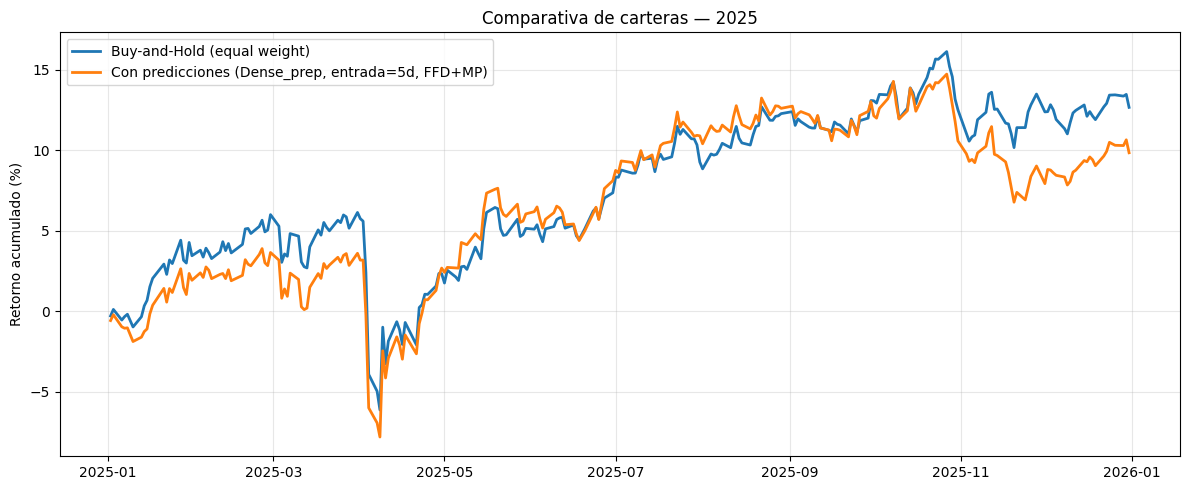

,Cartera,Preprocesado,Retorno 2025,Sharpe anualizado
0,Buy-and-Hold,Ninguno,12.67%,0.95
1,Con predicciones (Dense_prep),FFD + Denoising MP + StandardScaler,9.84%,0.76


In [9]:
fechas_2025 = retornos_2025_raw.index[:n_dias]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(fechas_2025, ret_acum_bah  * 100, label='Buy-and-Hold (equal weight)', linewidth=2)
ax.plot(fechas_2025, ret_acum_pred * 100,
        label=f'Con predicciones ({NOMBRE_GUARDADO}, entrada={VENTANA_ENTRADA}d, FFD+MP)',
        linewidth=2)
ax.set_ylabel('Retorno acumulado (%)')
ax.set_title('Comparativa de carteras — 2025')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

display(pd.DataFrame({
    'Cartera':           ['Buy-and-Hold', f'Con predicciones ({NOMBRE_GUARDADO})'],
    'Preprocesado':      ['Ninguno', 'FFD + Denoising MP + StandardScaler'],
    'Retorno 2025':      [f'{ret_acum_bah[-1]:.2%}',  f'{ret_acum_pred[-1]:.2%}'],
    'Sharpe anualizado': [f'{sharpe_bah:.2f}',         f'{sharpe_pred:.2f}'],
}))
